In [18]:
import numpy as np
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.cuda.amp import autocast
import matplotlib.pyplot as plt
import gc

DATA_ROOT = '/kaggle/input/competitions/anrf-aise-hack-phase-2-theme-2-pollution-forecasting-iitd/aisehack-theme-2'
TEST_IN = f'{DATA_ROOT}/test_in'

CKPT = '/kaggle/input/models/meet0527/best-model69/pytorch/default/1/best_model_p2 (2).pt'  # upload model here

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", DEVICE)

Device: cuda


In [19]:
MET_VARS = ['q2', 't2', 'u10', 'v10', 'swdown', 'pblh', 'psfc', 'rain']
EMISSION_VARS = ['PM25', 'NH3', 'SO2', 'NOx', 'NMVOC_e', 'NMVOC_finn', 'bio']

LOG_FEATURES = {'PM25', 'NH3', 'SO2', 'NOx', 'NMVOC_e', 'NMVOC_finn', 'bio', 'cpm25'}

In [20]:
def compute_stats(arr, key):
    arr = arr.astype(np.float32)
    if key in LOG_FEATURES:
        arr = np.log1p(arr * 1e9)
    return float(arr.mean()), float(arr.std() + 1e-8)

def normalize(arr, key):
    mean, std = norm_stats[key]
    arr = arr.astype(np.float32)
    if key in LOG_FEATURES:
        arr = np.log1p(arr * 1e9)
    return (arr - mean) / std

def denormalize(arr, key):
    mean, std = norm_stats[key]
    return np.expm1(arr * std + mean) / 1e9


# 🔥 LOAD ONLY DEC
dec_path = os.path.join(DATA_ROOT, 'raw', 'DEC_16')

dec_data = {'cpm25': np.load(os.path.join(dec_path, 'cpm25.npy')).astype(np.float32)}

for v in MET_VARS + EMISSION_VARS:
    fpath = os.path.join(dec_path, f'{v}.npy')
    if os.path.exists(fpath):
        dec_data[v] = np.load(fpath).astype(np.float32)

# 🔥 COMPUTE STATS ONLY FROM DEC
norm_stats = {}
for key in dec_data:
    norm_stats[key] = compute_stats(dec_data[key], key)

print("✅ Stats computed from DEC")

✅ Stats computed from DEC


In [21]:
# ── Required constants (make sure these are defined before running) ──
HIDDEN_DIM = 96
KERNEL_SIZE = 3
NUM_LAYERS = 3
HISTORY_PM = 10
FORECAST = 16
H, W = 140, 124

# ── Model ───────────────────────────────────────────────────────────

class ConvLSTMCell(nn.Module):
    def __init__(self, in_ch, hidden_ch, kernel_size):
        super().__init__()
        self.hidden_ch = hidden_ch
        self.conv = nn.Conv2d(in_ch + hidden_ch, 4 * hidden_ch,
                              kernel_size, padding=kernel_size // 2)
        self.ln = nn.GroupNorm(1, 4 * hidden_ch)

    def forward(self, x, h, c):
        gates = self.ln(self.conv(torch.cat([x, h], 1)))
        i, f, g, o = gates.chunk(4, 1)
        c = torch.sigmoid(f) * c + torch.sigmoid(i) * torch.tanh(g)
        h = torch.sigmoid(o) * torch.tanh(c)
        return h, c

    def init_hidden(self, B, H, W, device):
        return (torch.zeros(B, self.hidden_ch, H, W, device=device),
                torch.zeros(B, self.hidden_ch, H, W, device=device))


class SpatialAttention(nn.Module):
    def __init__(self, in_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, in_ch // 4, 1), nn.ReLU(),
            nn.Conv2d(in_ch // 4, 1, 1), nn.Sigmoid()
        )
    def forward(self, x): return x * self.conv(x)


class WindWarp(nn.Module):
    def __init__(self, u_idx, v_idx):
        super().__init__()
        self.u_idx, self.v_idx = u_idx, v_idx
        self.log_scale = nn.Parameter(torch.tensor(-3.0))

    def forward(self, pm, last_met, step=0):
        if self.u_idx is None: return pm
        B, _, H, W = pm.shape
        scale = torch.exp(self.log_scale) / (1.0 + 0.1 * step)
        u = last_met[:, self.u_idx:self.u_idx+1]
        v = last_met[:, self.v_idx:self.v_idx+1]

        xs = torch.linspace(-1, 1, W, device=pm.device)
        ys = torch.linspace(-1, 1, H, device=pm.device)
        gy, gx = torch.meshgrid(ys, xs, indexing='ij')
        grid = torch.stack([gx, gy], -1).unsqueeze(0).expand(B, -1, -1, -1)

        flow = torch.stack([u.squeeze(1), v.squeeze(1)], -1) * scale
        warped_g = (grid + flow).clamp(-1, 1)

        return F.grid_sample(pm, warped_g, align_corners=False,
                             mode='bilinear', padding_mode='border')


class SpatialEncoder(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.e1 = nn.Sequential(nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.ReLU())
        self.e2 = nn.Sequential(nn.Conv2d(in_ch, out_ch, 3, padding=2, dilation=2), nn.ReLU())
        self.e3 = nn.Sequential(nn.Conv2d(in_ch, out_ch, 3, padding=4, dilation=4), nn.ReLU())
        self.fuse = nn.Conv2d(out_ch * 3, out_ch, 1)

    def forward(self, x):
        return self.fuse(torch.cat([self.e1(x), self.e2(x), self.e3(x)], 1))


class EpisodeDetector(nn.Module):
    def __init__(self, in_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 16, 3, padding=1), nn.ReLU(),
            nn.Conv2d(16, 1, 1), nn.Sigmoid()
        )
    def forward(self, h): return self.net(h)


class Phase2Model(nn.Module):
    def __init__(self, met_channels, hidden_dim, kernel_size, num_layers, u_idx, v_idx):
        super().__init__()
        self.num_layers = num_layers
        enc_met_ch = hidden_dim // 2

        self.spatial_enc = SpatialEncoder(met_channels, enc_met_ch)
        self.wind_warp = WindWarp(u_idx, v_idx)
        self.episode_detect = EpisodeDetector(hidden_dim)

        self.enc_cells = nn.ModuleList()
        self.dec_cells = nn.ModuleList()

        for i in range(num_layers):
            enc_in = (1 + enc_met_ch) if i == 0 else hidden_dim
            dec_in = (1 + enc_met_ch + 1) if i == 0 else hidden_dim
            self.enc_cells.append(ConvLSTMCell(enc_in, hidden_dim, kernel_size))
            self.dec_cells.append(ConvLSTMCell(dec_in, hidden_dim, kernel_size))

        self.attn = SpatialAttention(hidden_dim)

        self.output_head = nn.Sequential(
            nn.Conv2d(hidden_dim, 64, 3, padding=1), nn.ReLU(),
            nn.Dropout2d(0.1),
            nn.Conv2d(64, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 1, 1)
        )

        self.episode_amp = nn.Sequential(
            nn.Conv2d(hidden_dim, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 1, 1), nn.Softplus()
        )

    def forward(self, pm_hist, met_hist, teacher_forcing_ratio=0.0, pm_fut_gt=None):
        B, T_hist, H, W = pm_hist.shape
        states = [cell.init_hidden(B, H, W, pm_hist.device) for cell in self.enc_cells]

        # Encoder
        for t in range(T_hist):
            enc_met = self.spatial_enc(met_hist[:, t])
            x = torch.cat([pm_hist[:, t:t+1], enc_met], 1)
            for i, cell in enumerate(self.enc_cells):
                h, c = states[i]
                h, c = cell(x, h, c)
                states[i] = (h, c)
                x = h

        last_met = met_hist[:, -1]
        enc_met_d = self.spatial_enc(last_met)

        preds = []
        prev_pm = pm_hist[:, -1:].clone()
        dec_states = list(states)

        for t in range(FORECAST):
            warped = self.wind_warp(prev_pm, last_met, step=t)
            h_cur = dec_states[-1][0]
            ep_map = self.episode_detect(h_cur)

            x = torch.cat([warped, enc_met_d, ep_map], 1)
            for i, cell in enumerate(self.dec_cells):
                h, c = dec_states[i]
                h, c = cell(x, h, c)
                dec_states[i] = (h, c)
                x = h

            x = self.attn(x)
            delta = self.output_head(x)
            amp = self.episode_amp(x)

            pred_t = prev_pm + delta + ep_map * amp
            pred_t = pred_t.clamp(-10, 30)

            preds.append(pred_t)
            prev_pm = pred_t

        return torch.cat(preds, dim=1)

In [22]:
other_keys = [k for k in MET_VARS + EMISSION_VARS if k in norm_stats]

u_idx = other_keys.index('u10') if 'u10' in other_keys else None
v_idx = other_keys.index('v10') if 'v10' in other_keys else None

C_met = len(other_keys)

model = Phase2Model(C_met, 96, 3, 3, u_idx, v_idx)

model.load_state_dict(torch.load(CKPT, map_location=DEVICE))
model = model.to(DEVICE).eval()

print("✅ Model loaded")

✅ Model loaded


In [23]:
# 🔹 Load test data
test_pm25_raw = np.load(os.path.join(TEST_IN, 'cpm25.npy')).astype(np.float32)
test_pm25_norm = normalize(test_pm25_raw, 'cpm25')

# 🔹 Basic info
N = test_pm25_norm.shape[0]
avail_keys = [k for k in other_keys if os.path.exists(os.path.join(TEST_IN, f'{k}.npy'))]

print("Samples:", N)
print("Features:", len(avail_keys))

# 🔹 Inference
all_preds = []
INFER_BATCH = 8

mean_pm, std_pm = norm_stats['cpm25']

with torch.no_grad():
    for i in range(0, N, INFER_BATCH):

        batch_mets = []
        for k in avail_keys:
            arr = np.load(os.path.join(TEST_IN, f'{k}.npy'), mmap_mode='r')
            slc = np.array(arr[i:i+INFER_BATCH]).astype(np.float32)
            batch_mets.append(normalize(slc, k))

        met_b = torch.tensor(np.stack(batch_mets, axis=2)).to(DEVICE)
        pm_b = torch.tensor(test_pm25_norm[i:i+INFER_BATCH]).to(DEVICE)

        with autocast(enabled=True):
            pred_norm = model(pm_b, met_b).cpu().numpy()

        pred = np.clip(np.expm1(pred_norm * std_pm + mean_pm) / 1e9, 0, 500)
        all_preds.append(pred)

# 🔹 Final output
preds = np.concatenate(all_preds, axis=0)

print("✅ Done:", preds.shape)

Samples: 218
Features: 15


/tmp/ipykernel_55/1496751571.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=True):


✅ Done: (218, 16, 140, 124)


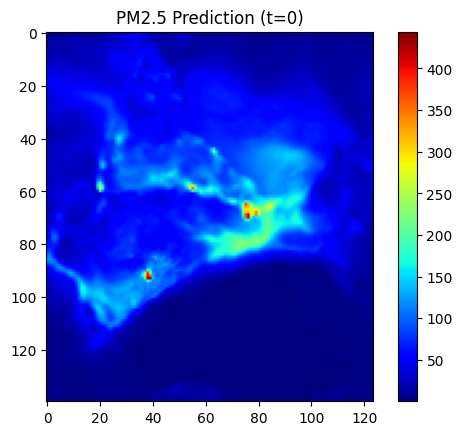

In [24]:
plt.imshow(preds[0, 0], cmap='jet')
plt.colorbar()
plt.title("PM2.5 Prediction (t=0)")
plt.show()

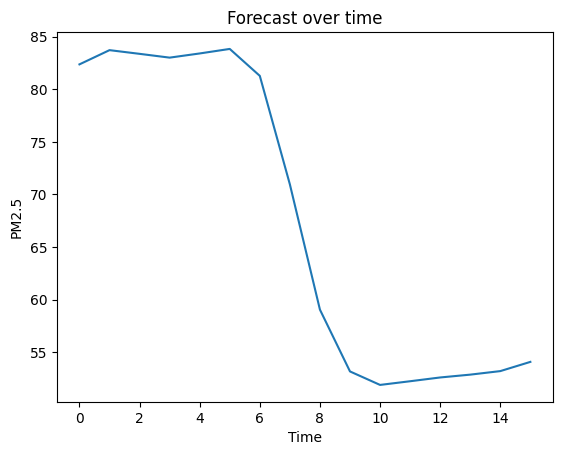

In [25]:
pixel = (70, 60)
plt.plot(preds[0, :, pixel[0], pixel[1]])
plt.title("Forecast over time")
plt.xlabel("Time")
plt.ylabel("PM2.5")
plt.show()

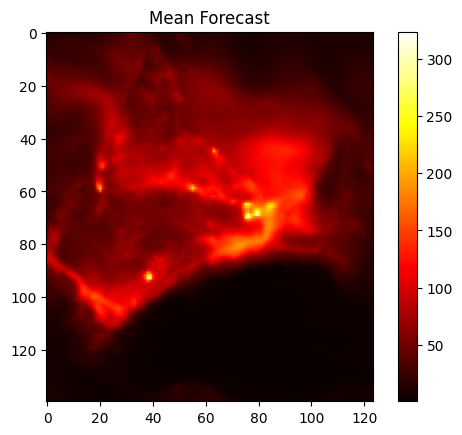

In [26]:
mean_map = preds.mean(axis=1)

plt.imshow(mean_map[0], cmap='hot')
plt.colorbar()
plt.title("Mean Forecast")
plt.show()

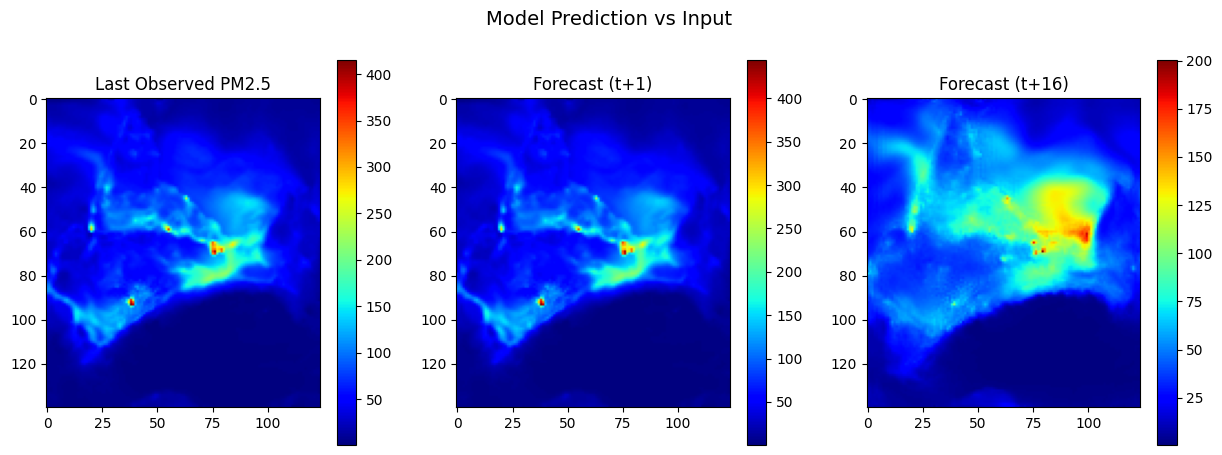

In [27]:
import matplotlib.pyplot as plt

# 🔹 Pick a sample
sample = 0

# 🔹 Last observed PM2.5 (input)
last_input = test_pm25_raw[sample, -1]

# 🔹 First forecast step
pred_0 = preds[sample, 0]

# 🔹 Last forecast step (far future)
pred_15 = preds[sample, -1]

plt.figure(figsize=(15,5))

# Input
plt.subplot(1,3,1)
plt.imshow(last_input, cmap='jet')
plt.title("Last Observed PM2.5")
plt.colorbar()

# Prediction t+1
plt.subplot(1,3,2)
plt.imshow(pred_0, cmap='jet')
plt.title("Forecast (t+1)")
plt.colorbar()

# Prediction t+16
plt.subplot(1,3,3)
plt.imshow(pred_15, cmap='jet')
plt.title("Forecast (t+16)")
plt.colorbar()

plt.suptitle("Model Prediction vs Input", fontsize=14)
plt.show()